In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
from probeinterface import write_probeinterface, read_probeinterface
import spikeinterface.exporters as sexp
from spikeinterface.core import write_binary_recording
from pathlib import Path
import pickle

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


成功读取数据，矩阵形状: (1, 5, 2)
有效数据点数量: 10 / 10

各clique的均值 (noise, label):
  Clique 0: 0.9825, 0.9762


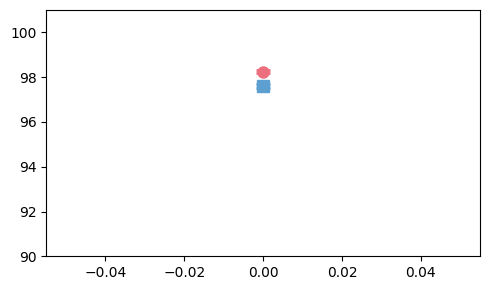

In [2]:
# 3. 读取所有clique所有重复的training_log.csv，提取best accuracy并绘制图表
base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim')
n_clique = 1
n_rep = 5  # model_1 到 model_5
date = 'mouse6_021322_natural_image_001'

# 初始化矩阵 (n_clique, n_rep, 2)
# 维度0: clique_id (0-3)
# 维度1: repetition (0-4, 对应model_1到model_5)
# 维度2: [noise_acc, label_acc]
accuracy_matrix = np.full((n_clique, n_rep, 2), np.nan)

# 遍历所有clique和重复
for clique_id in range(n_clique):
    clique_dir = base_dir / f'clique_{clique_id}'
    date_dir = clique_dir / f'{date}'
    
    for rep_idx in range(n_rep):
        model_dir = date_dir / f'model_{rep_idx + 1}'
        training_log_path = model_dir / 'training_log.csv'
        
        if not training_log_path.exists():
            print(f"警告: {training_log_path} 不存在，跳过")
            continue
        
        try:
            # 读取training_log.csv
            df = pd.read_csv(training_log_path)
            
            # 提取best accuracy（每列的最大值）
            if 'validation_acc_noise' in df.columns:
                best_noise_acc = df['validation_acc_noise'].max()
            else:
                print(f"警告: {training_log_path} 中没有validation_acc_noise列")
                best_noise_acc = np.nan
            
            if 'validation_acc_label' in df.columns:
                best_label_acc = df['validation_acc_label'].max()
            else:
                print(f"警告: {training_log_path} 中没有validation_acc_label列")
                best_label_acc = np.nan
            
            # 存储到矩阵中
            accuracy_matrix[clique_id, rep_idx, 0] = best_noise_acc
            accuracy_matrix[clique_id, rep_idx, 1] = best_label_acc
            
        except Exception as e:
            print(f"错误: 无法读取 {training_log_path}: {e}")
            continue

print(f"成功读取数据，矩阵形状: {accuracy_matrix.shape}")
print(f"有效数据点数量: {np.sum(~np.isnan(accuracy_matrix))} / {accuracy_matrix.size}")

# 计算每个clique的均值和标准差
clique_means = np.nanmean(accuracy_matrix, axis=1)  # (n_clique, 2)
clique_stds = np.nanstd(accuracy_matrix, axis=1)   # (n_clique, 2)

print(f"\n各clique的均值 (noise, label):")
for clique_id in range(n_clique):
    print(f"  Clique {clique_id}: {clique_means[clique_id, 0]:.4f}, {clique_means[clique_id, 1]:.4f}")

# 绘制点图+折线图+errorbar
fig, ax = plt.subplots(figsize=(5, 3))

clique_labels = [f'Clique {i}' for i in range(n_clique)]
x_positions = np.arange(n_clique)

# 颜色定义
noise_color = '#EC6F7E'
label_color = '#5E9FD1'

# 绘制noise分类的准确率
noise_means = clique_means[:, 0] * 100  # 转换为百分比
noise_stds = clique_stds[:, 0] * 100

# 绘制折线和errorbar（显示平均值点和误差棒）
ax.errorbar(x_positions, noise_means, yerr=noise_stds, 
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=noise_color, label='Noise Classification', 
           capsize=5, capthick=2, zorder=4)

label_means = clique_means[:, 1] * 100  # 转换为百分比
label_stds = clique_stds[:, 1] * 100

# 绘制折线和errorbar（显示平均值点和误差棒）
ax.errorbar(x_positions, label_means, yerr=label_stds, 
           marker='s', linestyle='-', linewidth=2, markersize=8,
           color=label_color, label='Label Classification', 
           capsize=5, capthick=2, zorder=4)

# 设置图表属性
ax.set_ylim([90, 101])

plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'train_accuracy_comparison.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
np.save(f'{base_dir}/train_accuracy_matrix.npy', accuracy_matrix)


In [31]:
for clique in [0]:
    with open(f"/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/clique_0/mouse6_022522_natural_image_001/calibration_model_1.pkl", 'rb') as f:
        calibration_model = pickle.load(f)

    train_neuron_inf_path = f'/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/clique_0/mouse6_021322_natural_image_001/neuron_inf.pickle'

    with open(train_neuron_inf_path, 'rb') as f:
        train_neuron_inf_dict = pickle.load(f)

    # 5. 从calibration_model中提取每个neuron的waveform和计算auto-correlogram

    # 窗口参数（用于时间轴显示）
    left_sample = 10
    right_sample = 20
    window_size = left_sample + right_sample  # 30 samples

    # 获取数据
    results_df = calibration_model['results_df']
    cluster_features = calibration_model.get('cluster_features', {})
    neuron_to_clusters = calibration_model.get('neuron_to_clusters', {})
    cluster_to_neuron_mapping = calibration_model.get('cluster_to_neuron_mapping', {})
    cluster_per_channel_waveforms = calibration_model.get('cluster_per_channel_waveforms', {})

    # 采样频率
    sampling_frequency = 10000

    # 获取所有非noise的neuron（从results_df）
    unique_neurons = results_df[results_df['predicted_label_str'] != 'noise']['predicted_label_str'].unique()
    print(f"找到 {len(unique_neurons)} 个非noise的neuron: {sorted(unique_neurons)}")

    # 存储每个neuron的结果
    neuron_results = {}

    for neuron_idx, neuron in enumerate(sorted(unique_neurons)):
        print(f"\n处理neuron {neuron} ({neuron_idx+1}/{len(unique_neurons)})")
        
        # 1. 从cluster_features中合并该neuron的所有clusters
        # 首先尝试从neuron_to_clusters获取cluster列表
        cluster_ids = neuron_to_clusters.get(neuron, [])
        
        # 如果没有，从cluster_to_neuron_mapping反向查找
        if len(cluster_ids) == 0:
            cluster_ids = [cid for cid, n in cluster_to_neuron_mapping.items() if str(n) == str(neuron)]
        
        if len(cluster_ids) == 0:
            print(f"  警告: neuron {neuron} 没有对应的clusters，跳过")
            continue
        
        print(f"  找到 {len(cluster_ids)} 个clusters: {cluster_ids}")
        
        # 收集该neuron所有clusters的position和position_waveform
        cluster_positions_1 = []
        cluster_positions_2 = []
        cluster_waveforms = []
        cluster_n_spikes = []
        
        for cluster_id in cluster_ids:
            if cluster_id not in cluster_features:
                print(f"    警告: cluster {cluster_id} 不在cluster_features中，跳过")
                continue
            
            cluster_data = cluster_features[cluster_id]
            pos_1 = cluster_data.get('position_1', None)
            pos_2 = cluster_data.get('position_2', None)
            position_waveform = cluster_data.get('position_waveform', None)
            n_spikes = cluster_data.get('n_spikes', 0)
            
            if pos_1 is not None and pos_2 is not None and position_waveform is not None:
                cluster_positions_1.append(pos_1)
                cluster_positions_2.append(pos_2)
                cluster_waveforms.append(np.asarray(position_waveform, dtype=np.float32))
                cluster_n_spikes.append(n_spikes)
        
        if len(cluster_waveforms) == 0:
            print(f"  警告: neuron {neuron} 没有有效的cluster数据，跳过")
            continue
        
        # 计算该neuron的平均position（加权平均，权重为n_spikes）
        if len(cluster_positions_1) > 0:
            total_spikes = sum(cluster_n_spikes)
            if total_spikes > 0:
                weights = np.array(cluster_n_spikes) / total_spikes
                neuron_position_1 = np.average(cluster_positions_1, weights=weights)
                neuron_position_2 = np.average(cluster_positions_2, weights=weights)
            else:
                neuron_position_1 = np.mean(cluster_positions_1)
                neuron_position_2 = np.mean(cluster_positions_2)
        else:
            neuron_position_1 = 0.0
            neuron_position_2 = 0.0
        
        # 计算该neuron的平均position_waveform（加权平均）
        # 确保所有waveform长度一致
        waveform_lengths = [len(wf) for wf in cluster_waveforms]
        if len(set(waveform_lengths)) > 1:
            min_len = min(waveform_lengths)
            cluster_waveforms = [wf[:min_len] for wf in cluster_waveforms]
            print(f"    警告: waveform长度不一致，截断到最小长度 {min_len}")
        
        if len(cluster_waveforms) > 0:
            total_spikes = sum(cluster_n_spikes)
            if total_spikes > 0:
                weights = np.array(cluster_n_spikes) / total_spikes
                neuron_position_waveform = np.average(cluster_waveforms, axis=0, weights=weights)
            else:
                neuron_position_waveform = np.mean(cluster_waveforms, axis=0)
        else:
            neuron_position_waveform = np.array([])
        
        # 2. 从results_df获取该neuron的spike times
        neuron_spikes = results_df[results_df['predicted_label_str'] == neuron].copy()
        
        if len(neuron_spikes) == 0:
            print(f"  警告: neuron {neuron} 在results_df中没有spikes，跳过")
            continue
        
        spike_times_samples = neuron_spikes['spike_time'].values
        spike_times_seconds = spike_times_samples / sampling_frequency
        
        print(f"  找到 {len(spike_times_samples)} 个spikes")
        print(f"  Position: ({neuron_position_1:.2f}, {neuron_position_2:.2f})")
        print(f"  Waveform length: {len(neuron_position_waveform)}")
        
        # 3. 计算auto-correlogram（-200到200ms，对称）
        if len(spike_times_seconds) > 1:
            sorted_times = np.sort(spike_times_seconds)
            
            # 创建auto-correlogram的bins（-200到200ms，1ms bins，对称）
            max_lag_ms = 200
            bin_size_ms = 1
            correlogram_bins = np.arange(-max_lag_ms, max_lag_ms + bin_size_ms, bin_size_ms) / 1000.0  # 转换为秒
            
            # 计算所有spike pairs之间的时间间隔（包括正负间隔）
            intervals_list = []
            for i in range(len(sorted_times)):
                # 计算与后续spikes的间隔（正间隔）
                future_times = sorted_times[i+1:] - sorted_times[i]
                valid_mask = future_times <= 0.2  # 只考虑200ms内
                if np.any(valid_mask):
                    intervals_list.extend(future_times[valid_mask].tolist())
                
                # 计算与前面spikes的间隔（负间隔）
                past_times = sorted_times[i] - sorted_times[:i]
                valid_mask = past_times <= 0.2  # 只考虑200ms内
                if np.any(valid_mask):
                    intervals_list.extend((-past_times[valid_mask]).tolist())  # 负号表示负间隔
            
            if len(intervals_list) > 0:
                intervals = np.array(intervals_list)
                # 计算histogram（包含正负间隔）
                correlogram, _ = np.histogram(intervals, bins=correlogram_bins)
                correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
            else:
                correlogram = np.zeros(len(correlogram_bins) - 1)
                correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
        else:
            correlogram_bins = np.arange(-200, 201, 1) / 1000.0
            correlogram = np.zeros(len(correlogram_bins) - 1)
            correlogram_centers = (correlogram_bins[:-1] + correlogram_bins[1:]) / 2
        
        # 4. 获取channel_id（从train_neuron_inf_dict）
        channel_id = []
        neuron_info = None
        for neuron_name, neuron_data in train_neuron_inf_dict.items():
            if str(neuron_name) == str(neuron):
                neuron_info = neuron_data
                channel_id = neuron_info.get('channel_id', [])
                break
        
        # 5. 提取channel_waveform（从cluster_per_channel_waveforms）
        # 直接按照列索引顺序提取所有channels的waveform
        channel_waveform_list = []  # 列表，按照列索引顺序存储所有channel的waveform
        
        if len(cluster_per_channel_waveforms) > 0:
            # 获取第一个cluster的waveform来确定列数
            first_cluster_id = None
            for cid in cluster_ids:
                if cid in cluster_per_channel_waveforms:
                    first_cluster_id = cid
                    break
            
            if first_cluster_id is not None:
                first_cluster_wf = cluster_per_channel_waveforms[first_cluster_id]
                n_cols = first_cluster_wf.shape[1]
                
                # 收集该neuron所有clusters的channel waveforms（按列索引）
                cluster_channel_waveforms_list = []  # 每个元素是一个数组 (window_size, n_channels)
                cluster_n_spikes_list = []
                
                for cluster_id in cluster_ids:
                    if cluster_id in cluster_per_channel_waveforms:
                        cluster_channel_wf = cluster_per_channel_waveforms[cluster_id]  # (window_size, n_channels)
                        cluster_channel_waveforms_list.append(cluster_channel_wf)
                        cluster_n_spikes_list.append(cluster_features[cluster_id].get('n_spikes', 0))
                
                # 对每个channel（列索引），合并所有clusters的waveform（加权平均）
                if len(cluster_channel_waveforms_list) > 0:
                    total_spikes_for_weight = sum(cluster_n_spikes_list)
                    
                    for col_idx in range(n_cols):
                        channel_waveforms_list = []
                        weights_list = []
                        
                        for i, cluster_channel_wf in enumerate(cluster_channel_waveforms_list):
                            if col_idx < cluster_channel_wf.shape[1]:
                                channel_waveforms_list.append(cluster_channel_wf[:, col_idx])  # (window_size,)
                                if total_spikes_for_weight > 0:
                                    weights_list.append(cluster_n_spikes_list[i])
                        
                        if len(channel_waveforms_list) > 0:
                            # 确保所有waveform长度一致
                            waveform_lengths = [len(wf) for wf in channel_waveforms_list]
                            if len(set(waveform_lengths)) > 1:
                                min_len = min(waveform_lengths)
                                channel_waveforms_list = [wf[:min_len] for wf in channel_waveforms_list]
                            
                            # 加权平均
                            if len(weights_list) > 0 and sum(weights_list) > 0:
                                weights = np.array(weights_list) / sum(weights_list)
                                channel_waveform_list.append(np.average(channel_waveforms_list, axis=0, weights=weights))
                            else:
                                channel_waveform_list.append(np.mean(channel_waveforms_list, axis=0))
                        else:
                            channel_waveform_list.append(np.array([]))
        
        # 存储结果
        neuron_results[neuron] = {
            'position_1': neuron_position_1,
            'position_2': neuron_position_2,
            'position_waveform': neuron_position_waveform,  # 1D array (window_size,)
            'channel_id': channel_id,
            'channel_waveform': channel_waveform_list,  # 列表，按照列索引顺序存储所有channel的waveform
            'spike_times_samples': spike_times_samples,
            'spike_times_seconds': spike_times_seconds,
            'correlogram': correlogram,
            'correlogram_centers': correlogram_centers,
            'n_spikes': len(spike_times_samples),
            'n_clusters': len(cluster_ids)
        }
        

    left_sample = 10
    right_sample = 20
    window_size = left_sample + right_sample  # 30 samples


    # 采样频率
    sampling_frequency = 10000

    # 获取所有30个channel的完整列表
    # 由于cluster_per_channel_waveforms有30列，我们需要知道这30列对应的channel_id
    # 这里我们尝试从所有neurons中找到一个包含所有30个channels的neuron，或者收集所有唯一的channel_id
    all_channel_ids_set = set()
    for neuron_data in neuron_results.values():
        channel_ids = neuron_data.get('channel_id', [])
        all_channel_ids_set.update(channel_ids)
    
    # 尝试找到一个包含所有30个channels的neuron（如果存在）
    all_30_channel_ids = None
    if len(neuron_results) > 0:
        first_neuron_data = list(neuron_results.values())[0]
        n_channels_total = len(first_neuron_data.get('channel_waveform', []))
        
        # 查找是否有neuron的channel_id列表长度等于总channel数
        for neuron_data in neuron_results.values():
            channel_ids = neuron_data.get('channel_id', [])
            if len(channel_ids) == n_channels_total:
                all_30_channel_ids = channel_ids  # 假设这个neuron的channel_id顺序对应列索引顺序
                break
        
        # 如果没有找到，使用收集到的所有channel_id并排序（可能不完整）
        if all_30_channel_ids is None:
            sorted_channel_ids = sorted(list(all_channel_ids_set))
            if len(sorted_channel_ids) == n_channels_total:
                all_30_channel_ids = sorted_channel_ids
            else:
                # 如果仍然不完整，使用排序后的列表（可能少于30个）
                all_30_channel_ids = sorted_channel_ids
    else:
        all_30_channel_ids = []

    # 计算每个neuron的channel_waveform的最大最小值（用于统一scale，以neuron为单位）

    # 创建时间轴（毫秒）- left 10 right 20
    time_points_ms = np.arange(-left_sample, right_sample) / sampling_frequency * 1000  # 转换为毫秒，中心在0

    # 1. 绘制waveform PDF
    output_waveform_pdf = f'{base_dir}/neuron_waveforms.pdf'
    print(f"\n绘制waveform PDF: {output_waveform_pdf}")

    with PdfPages(output_waveform_pdf) as pdf:
        for neuron in sorted(neuron_results.keys()):
            data = neuron_results[neuron]
            
            # 获取channel_waveform（列表，按列索引顺序）
            channel_waveform_list = data.get('channel_waveform', [])
            
            if len(channel_waveform_list) == 0:
                print(f"  跳过neuron {neuron}: channel_waveform为空")
                continue
            
            n_channels = len(channel_waveform_list)
            
            # 按照channel_id的字母数字顺序排序
            # 使用之前收集的all_30_channel_ids作为列索引到channel_id的映射
            if all_30_channel_ids is not None and len(all_30_channel_ids) == n_channels:
                # 创建列索引到channel_id的映射（假设all_30_channel_ids的顺序对应列索引顺序）
                idx_to_channel_id = {idx: ch_id for idx, ch_id in enumerate(all_30_channel_ids)}
                
                # 按照channel_id的字母数字顺序排序
                sorted_channel_ids = sorted(all_30_channel_ids)  # 按照字母数字顺序排序（A-000, A-001, ...）
                
                # 按照排序后的channel_id顺序重新排列waveform
                sorted_channel_waveform_list = []
                for ch_id in sorted_channel_ids:
                    # 找到这个channel_id对应的列索引
                    col_idx = all_30_channel_ids.index(ch_id) if ch_id in all_30_channel_ids else None
                    if col_idx is not None and col_idx < len(channel_waveform_list):
                        sorted_channel_waveform_list.append(channel_waveform_list[col_idx])
                
                channel_waveform_list = sorted_channel_waveform_list
                channel_ids = sorted_channel_ids
            else:
                # 如果无法获取完整的channel_id列表，使用列索引作为标识
                channel_ids = [f'Channel {i}' for i in range(n_channels)]
            
            # 计算该neuron所有channel waveform的最大最小值（用于统一scale）
            all_channel_waveform_values = []
            for wf in channel_waveform_list:
                if len(wf) > 0:
                    all_channel_waveform_values.append(wf.flatten())
            
            if len(all_channel_waveform_values) > 0:
                all_wf_array = np.concatenate(all_channel_waveform_values)
                neuron_waveform_min = np.min(all_wf_array)
                neuron_waveform_max = np.max(all_wf_array)
                waveform_margin = (neuron_waveform_max - neuron_waveform_min) * 0.1
                neuron_waveform_ylim = [neuron_waveform_min - waveform_margin, neuron_waveform_max + waveform_margin]
            else:
                neuron_waveform_ylim = [-1, 1]
            
            # 创建subplot布局（根据n_channels确定行列数）
            if n_channels <= 4:
                n_rows = 1
                n_cols = n_channels
            elif n_channels <= 8:
                n_rows = 2
                n_cols = 4
            elif n_channels <= 12:
                n_rows = 3
                n_cols = 4
            elif n_channels <= 16:
                n_rows = 4
                n_cols = 4
            elif n_channels <= 20:
                n_rows = 4
                n_cols = 5
            elif n_channels <= 25:
                n_rows = 5
                n_cols = 5
            elif n_channels <= 30:
                n_rows = 6
                n_cols = 5
            elif n_channels <= 36:
                n_rows = 6
                n_cols = 6
            else:
                # 对于更多通道，使用6列布局
                n_rows = (n_channels + 5) // 6  # 向上取整
                n_cols = 6
            
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
            # 将axes转换为列表格式
            if n_channels == 1:
                axes = [axes]
            elif n_rows == 1 or n_cols == 1:
                axes = axes if isinstance(axes, np.ndarray) else [axes]
                axes = list(axes)
            else:
                axes = axes.flatten()
            
            # 获取neuron的position信息
            neuron_pos = (data.get('position_1', 0), data.get('position_2', 0))
            n_spikes = data.get('n_spikes', 0)
            n_clusters = data.get('n_clusters', 0)
            
            # 为每个channel绘制waveform（按照列表顺序）
            for i, waveform in enumerate(channel_waveform_list):
                if i >= len(axes):
                    break
                
                ax = axes[i]
                
                if len(waveform) == 0:
                    ax.axis('off')
                    continue
                
                if len(waveform) != window_size:
                    print(f"    警告: neuron {neuron} channel {i} 的waveform尺寸不匹配 ({len(waveform)} != {window_size})")
                    ax.axis('off')
                    continue
                
                ax.plot(time_points_ms, waveform, 'b-', linewidth=10, color='#EC6F7E')
                ax.set_ylim(neuron_waveform_ylim)
                
                # 如果有channel_id列表且长度匹配，使用channel_id作为标题；否则使用列索引
                if len(channel_ids) > i:
                    ax.set_title(f'Channel {channel_ids[i]}', fontsize=10)
                else:
                    ax.set_title(f'Channel {i}', fontsize=10)
                
                # 在A-000（第一个channel，索引为0）上添加scale bar
                if i == 0:
                    # scale bar参数：竖线，长度为100（y轴方向）
                    scale_bar_length = 100
                    
                    # 使用已知的坐标范围
                    x_range = [time_points_ms[0], time_points_ms[-1]]
                    y_range = neuron_waveform_ylim
                    
                    # scale bar位置：放在x轴的右侧，y轴的底部
                    scale_bar_x = x_range[0] + (x_range[1] - x_range[0]) * 0.85  # 放在x轴的85%位置（右侧）
                    scale_bar_y_bottom = y_range[0] + (y_range[1] - y_range[0]) * 0.1  # 距离底部10%
                    scale_bar_y_top = scale_bar_y_bottom + scale_bar_length
                    
                    # 绘制scale bar竖线（黑色，线宽2）
                    ax.plot([scale_bar_x, scale_bar_x], [scale_bar_y_bottom, scale_bar_y_top], 
                           'k-', linewidth=4, color='black', zorder=10)
                
                ax.axis('off')
            
            # 隐藏多余的subplot
            for i in range(n_channels, len(axes)):
                axes[i].axis('off')
            
            # 设置整体标题
            fig.suptitle(f'Neuron {neuron} - Position: {neuron_pos}', fontsize=12)
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

    print(f"✓ 已保存waveform PDF: {output_waveform_pdf} (共 {len(neuron_results)} 页)")

    output_correlogram_pdf = f'{base_dir}/neuron_autocorrelograms.pdf'

    with PdfPages(output_correlogram_pdf) as pdf:
        for neuron in sorted(neuron_results.keys()):
            data = neuron_results[neuron]

            correlogram = data['correlogram']
            correlogram_centers = data['correlogram_centers'] * 1000  
            n_spikes = data.get('n_spikes', 0)
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # 绘制柱状图
            ax.bar(correlogram_centers, correlogram, width=1.0, color='gray', edgecolor='gray', linewidth=0.5)
            
            ax.set_xlim([-200, 200])
            ax.axis('off')
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close()

    print(f"✓ 已保存auto-correlogram PDF: {output_correlogram_pdf} (共 {len(neuron_results)} 页)")


找到 30 个非noise的neuron: ['10', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '25', '26', '28', '31', '32', '33', '36', '4', '41', '42', '43', '44', '45', '46', '47', '5', '7', '9']

处理neuron 10 (1/30)
  找到 1 个clusters: [np.int64(21)]
  找到 1717 个spikes
  Position: (603.92, 78.77)
  Waveform length: 30

处理neuron 13 (2/30)
  找到 5 个clusters: [np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
  找到 719 个spikes
  Position: (46.92, 94.73)
  Waveform length: 30

处理neuron 14 (3/30)
  找到 3 个clusters: [np.int64(30), np.int64(32), np.int64(34)]
  找到 9009 个spikes
  Position: (600.69, 54.38)
  Waveform length: 30

处理neuron 15 (4/30)
  找到 2 个clusters: [np.int64(31), np.int64(33)]
  找到 3182 个spikes
  Position: (600.17, 48.08)
  Waveform length: 30

处理neuron 16 (5/30)
  找到 2 个clusters: [np.int64(35), np.int64(37)]
  找到 465 个spikes
  Position: (41.48, 59.43)
  Waveform length: 30

处理neuron 17 (6/30)
  找到 3 个clusters: [np.int64(36), np.int64(38), np.int64(39)]
  找到 47

In [2]:
# 提取calibration_model的评估指标

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim')

# 定义参数
n_clique = 1
dates = [
    'mouse6_022522_natural_image_001',
    'mouse6_031722_natural_image_001',
    'mouse6_042422_natural_image_001',
    'mouse6_052422_natural_image_001'
    # 'mouse6_062422_natural_image_001',
    # 'mouse6_072322_natural_image_001',
    # 'mouse6_082322_natural_image_001',
    # 'mouse6_092422_natural_image_001',
    # 'mouse6_102122_natural_image_001',
    # 'mouse6_112022_natural_image_001',
    # 'mouse6_122022_natural_image_001'
]
n_date = len(dates)
n_rep = 5  # model_1 到 model_5

# 定义4个指标
metric_names = [
    'noise_classifier_accuracy',      # 指标0
    'accuracy_excluding_noise',       # 指标1
    'n_overlapping_neurons',          # 指标2
    'n_matched_neurons'              # 指标3
]

# 初始化矩阵: (4, 4, n_date, 5)
# 维度0: clique_id (0-3)
# 维度1: metric_idx (0-3)
# 维度2: date_idx (0到n_date-1)
# 维度3: rep_idx (0-4, 对应model_1到model_5)
calibration_metrics_matrix = np.full((n_clique, len(metric_names), n_date, n_rep), np.nan)

print(f"开始提取calibration_model指标...")
print(f"矩阵形状: {calibration_metrics_matrix.shape}")
print(f"指标: {metric_names}\n")

# 遍历所有clique、日期和重复
total_files = 0
success_files = 0

for clique_id in range(n_clique):
    clique_dir = base_dir / f'clique_{clique_id}'
    
    for date_idx, date in enumerate(dates):
        date_dir = clique_dir / f'{date}'
        
        for rep_idx in range(n_rep):
            model_num = rep_idx + 1
            calibration_model_path = date_dir / f'calibration_model_{model_num}.pkl'
            total_files += 1
            
            if not calibration_model_path.exists():
                continue
            
            try:
                # 读取calibration_model
                with open(calibration_model_path, 'rb') as f:
                    calibration_model = pickle.load(f)
                
                # 提取4个指标
                for metric_idx, metric_name in enumerate(metric_names):
                    value = calibration_model.get(metric_name, None)
                    if value is not None:
                        calibration_metrics_matrix[clique_id, metric_idx, date_idx, rep_idx] = value
                
                success_files += 1
                
            except Exception as e:
                print(f"错误: 无法读取 {calibration_model_path}: {e}")
                continue

print(f"\n提取完成！")
print(f"成功读取: {success_files}/{total_files} 个文件")
print(f"有效数据点: {np.sum(~np.isnan(calibration_metrics_matrix))} / {calibration_metrics_matrix.size}")

# 打印各指标的有效数据统计
print(f"\n各指标的有效数据统计:")
for metric_idx, metric_name in enumerate(metric_names):
    valid_count = np.sum(~np.isnan(calibration_metrics_matrix[:, metric_idx, :, :]))
    total_count = n_clique * n_date * n_rep
    print(f"  {metric_name}: {valid_count}/{total_count} ({valid_count/total_count*100:.1f}%)")

# 保存矩阵
output_matrix_path = base_dir / 'calibration_metrics_matrix.npy'
np.save(output_matrix_path, calibration_metrics_matrix)



开始提取calibration_model指标...
矩阵形状: (1, 4, 4, 5)
指标: ['noise_classifier_accuracy', 'accuracy_excluding_noise', 'n_overlapping_neurons', 'n_matched_neurons']


提取完成！
成功读取: 20/20 个文件
有效数据点: 80 / 80

各指标的有效数据统计:
  noise_classifier_accuracy: 20/20 (100.0%)
  accuracy_excluding_noise: 20/20 (100.0%)
  n_overlapping_neurons: 20/20 (100.0%)
  n_matched_neurons: 20/20 (100.0%)


数据形状: (1, 4, 4, 5)
noise_classifier_accuracy均值范围: [0.9437, 0.9615]
accuracy_excluding_noise均值范围: [0.8515, 0.8774]


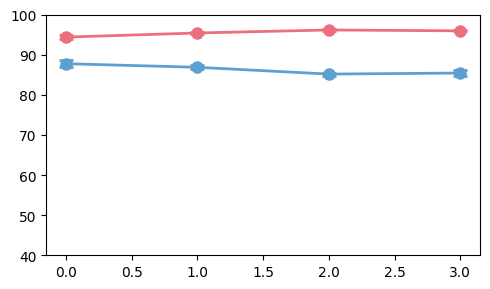

In [3]:
# 绘制calibration_model的评估指标折线图

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim')

# 加载矩阵（如果还没有运行前面的cell）
if 'calibration_metrics_matrix' not in globals():
    calibration_metrics_matrix = np.load(base_dir / 'calibration_metrics_matrix.npy')

n_clique = 1
dates = [
    'mouse6_022522_natural_image_001',
    'mouse6_031722_natural_image_001',
    'mouse6_042422_natural_image_001',
    'mouse6_052422_natural_image_001',
    # 'mouse6_062422_natural_image_001',
    # 'mouse6_072322_natural_image_001',
    # 'mouse6_082322_natural_image_001',
    # 'mouse6_092422_natural_image_001',
    # 'mouse6_102122_natural_image_001',
    # 'mouse6_112022_natural_image_001',
    # 'mouse6_122022_natural_image_001'
]
n_date = len(dates)
n_rep = 5  # model_1 到 model_5

# 指标索引
# 0: noise_classifier_accuracy
# 1: accuracy_excluding_noise
noise_acc_idx = 0
label_acc_idx = 1

# 提取两个指标的数据
# calibration_metrics_matrix形状: (n_clique, n_metrics, n_date, n_rep)
noise_acc_data = calibration_metrics_matrix[:, noise_acc_idx, :, :]  # (n_clique, n_date, n_rep)
label_acc_data = calibration_metrics_matrix[:, label_acc_idx, :, :]  # (n_clique, n_date, n_rep)

# 整合所有clique的数据：将clique维度合并到rep维度
# 重新reshape: (n_clique, n_date, n_rep) -> (n_date, n_clique * n_rep)
noise_acc_combined = noise_acc_data.reshape(n_clique * n_date, -1).T  # (n_rep, n_clique * n_date)
label_acc_combined = label_acc_data.reshape(n_clique * n_date, -1).T  # (n_rep, n_clique * n_date)

# 对每个日期，计算所有clique和所有重复的均值和标准差
noise_means = []
noise_stds = []
label_means = []
label_stds = []

for date_idx in range(n_date):
    # 提取该日期所有clique所有重复的数据
    noise_date_data = noise_acc_data[:, date_idx, :].flatten()  # (n_clique * n_rep,)
    label_date_data = label_acc_data[:, date_idx, :].flatten()  # (n_clique * n_rep,)
    
    # 计算均值和标准差（排除NaN）
    noise_mean = np.nanmean(noise_date_data)
    noise_std = np.nanstd(noise_date_data)
    label_mean = np.nanmean(label_date_data)
    label_std = np.nanstd(label_date_data)
    
    noise_means.append(noise_mean)
    noise_stds.append(noise_std)
    label_means.append(label_mean)
    label_stds.append(label_std)

noise_means = np.array(noise_means)
noise_stds = np.array(noise_stds)
label_means = np.array(label_means)
label_stds = np.array(label_stds)

print(f"数据形状: {calibration_metrics_matrix.shape}")
print(f"noise_classifier_accuracy均值范围: [{np.nanmin(noise_means):.4f}, {np.nanmax(noise_means):.4f}]")
print(f"accuracy_excluding_noise均值范围: [{np.nanmin(label_means):.4f}, {np.nanmax(label_means):.4f}]")

# 绘制折线图
fig, ax = plt.subplots(figsize=(5, 3))

# 颜色定义
noise_color = '#EC6F7E'
label_color = '#5E9FD1'

# x轴位置（日期）
x_positions = np.arange(n_date)
date_labels = [f'Date {date}' for date in dates]

# 绘制noise_classifier_accuracy
noise_mean_pct = noise_means * 100  # 转换为百分比
noise_std_pct = noise_stds * 100

ax.errorbar(x_positions, noise_mean_pct, yerr=noise_std_pct,
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=noise_color, label='Noise Classifier', 
           capsize=5, capthick=2, zorder=4)

# 绘制accuracy_excluding_noise
label_mean_pct = label_means * 100  # 转换为百分比
label_std_pct = label_stds * 100

ax.errorbar(x_positions, label_mean_pct, yerr=label_std_pct,
           marker='o', linestyle='-', linewidth=2, markersize=8,
           color=label_color, label='Label Classifier', 
           capsize=5, capthick=2, zorder=4)

# 设置图表属性
ax.set_ylim([40, 100])

plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'calibration_accuracy_comparison.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
plt.show()


n_overlapping_neurons (求和值): [30. 31. 34. 34.]
n_matched_neurons (均值): [31.  31.2 33.  33.2]
n_matched_neurons (标准差): [0.89442719 0.4        0.         0.4       ]

✓ 已保存柱状图: /media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim/neuron_counts_barplot.pdf


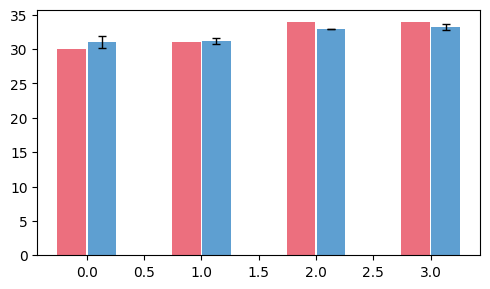

In [4]:
# 绘制n_overlapping_neurons和n_matched_neurons的柱状图

base_dir = Path('/media/ubuntu/sda/mouse_test/sorted/recordings_30_channel_12_months_mouse6_natim')

# 加载矩阵（如果还没有运行前面的cell）
if 'calibration_metrics_matrix' not in globals():
    calibration_metrics_matrix = np.load(base_dir / 'calibration_metrics_matrix.npy')

n_clique = 1
dates = [
    'mouse6_022522_natural_image_001',
    'mouse6_031722_natural_image_001',
    'mouse6_042422_natural_image_001',
    'mouse6_052422_natural_image_001',
    # 'mouse6_062422_natural_image_001',
    # 'mouse6_072322_natural_image_001',
    # 'mouse6_082322_natural_image_001',
    # 'mouse6_092422_natural_image_001',
    # 'mouse6_102122_natural_image_001',
    # 'mouse6_112022_natural_image_001',
    # 'mouse6_122022_natural_image_001'
]
n_date = len(dates)
n_rep = 5  # model_1 到 model_5

# 指标索引
# 2: n_overlapping_neurons
# 3: n_matched_neurons
overlapping_idx = 2
matched_idx = 3

# 提取两个指标的数据
# calibration_metrics_matrix形状: (n_clique, n_metrics, n_date, n_rep)
overlapping_data = calibration_metrics_matrix[:, overlapping_idx, :, :]  # (n_clique, n_date, n_rep)
matched_data = calibration_metrics_matrix[:, matched_idx, :, :]  # (n_clique, n_date, n_rep)

# 对每个日期，计算4个clique的求和值
overlapping_sums = []  # 每个日期，所有clique的求和（只取一个重复，因为5个重复都一样）
matched_means = []     # 每个日期，所有clique的均值（跨重复）
matched_stds = []      # 每个日期，所有clique的标准差（跨重复）

for date_idx in range(n_date):
    # n_overlapping_neurons: 只取第一个重复（rep_idx=0），然后对4个clique求和
    overlapping_date_data = overlapping_data[:, date_idx, 0]  # (n_clique,)
    overlapping_sum = np.nansum(overlapping_date_data)  # 对4个clique求和
    overlapping_sums.append(overlapping_sum)
    
    # n_matched_neurons: 对每个重复，先对4个clique求和，然后计算跨重复的均值和标准差
    matched_date_data = matched_data[:, date_idx, :]  # (n_clique, n_rep)
    # 对每个重复，先对clique求和，得到(n_rep,)的数组
    matched_per_rep = np.nansum(matched_date_data, axis=0)  # (n_rep,)
    # 计算跨重复的均值和标准差
    matched_mean = np.nanmean(matched_per_rep)
    matched_std = np.nanstd(matched_per_rep)
    matched_means.append(matched_mean)
    matched_stds.append(matched_std)

overlapping_sums = np.array(overlapping_sums)
matched_means = np.array(matched_means)
matched_stds = np.array(matched_stds)

print(f"n_overlapping_neurons (求和值): {overlapping_sums}")
print(f"n_matched_neurons (均值): {matched_means}")
print(f"n_matched_neurons (标准差): {matched_stds}")

# 绘制柱状图
fig, ax = plt.subplots(figsize=(5, 3))

# 颜色定义
overlapping_color = '#EC6F7E'
matched_color = '#5E9FD1'

# x轴位置
x_positions = np.arange(n_date)
bar_width = 0.25  # 柱子宽度

# 绘制n_overlapping_neurons的柱子（无errorbar）
bars1 = ax.bar(x_positions - bar_width/2 *1.05, overlapping_sums, bar_width,
               color=overlapping_color, label='n_overlapping_neurons')

# 绘制n_matched_neurons的柱子（带errorbar）
bars2 = ax.bar(x_positions + bar_width/2 *1.05, matched_means, bar_width,
               color=matched_color, label='n_matched_neurons', yerr=matched_stds,
               capsize=3, error_kw={'linewidth': 1, 'capthick': 1})



plt.tight_layout()

# 保存图表
output_pdf_path = base_dir / 'neuron_counts_barplot.pdf'
plt.savefig(output_pdf_path, dpi=300, bbox_inches='tight')
print(f"\n✓ 已保存柱状图: {output_pdf_path}")

plt.show()
